# OPSD PowerDesk: Day-Ahead Load Forecasting & Anomaly Detection

## Objective
The goal of this project is to build a robust day-ahead (24-step) electric load forecasting system for three European countries (Germany, France, Spain) using Open Power System Data (OPSD). The system includes:

1.  **Time Series Analysis:** Decomposition (STL), stationarity tests (ADF), and order selection (ACF/PACF).
2.  **Forecasting:** SARIMA modeling with an expanding window backtest.
3.  **Anomaly Detection:** A hybrid approach using statistical Z-scores and a Machine Learning classifier (Silver Labels).
4.  **Live Simulation:** A simulated production environment with drift detection and online model adaptation.

In [1]:
!pip install pmdarima statsmodels pandas matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests

COUNTRIES = ['DE', 'FR', 'ES']
OPSD_URL = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"
FILENAME = "opsd_data.csv"

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.3 MB/s eta 0:00:00


### 1. Data Ingestion & Setup
We begin by setting up the environment and downloading the hourly time series data from the OPSD repository.

**Configuration:**
* **Countries:** Germany (DE), France (FR), Spain (ES).
* **Target Variable:** Electricity Load (`load_actual_entsoe_transparency`).

In [2]:
def download_opsd_data(url, filename):
    """Downloads the OPSD Time Series data if not present."""
    if not os.path.exists(filename):
        print(f"Downloading data from {url}...")
        response = requests.get(url)
        with open(filename, 'wb') as f:
            f.write(response.content)
        print("Download complete.")
    else:
        print("Data file already exists.")

download_opsd_data(OPSD_URL, FILENAME)

print("Loading dataset... (this may take a moment)")
df_raw = pd.read_csv(FILENAME, parse_dates=['utc_timestamp'], index_col='utc_timestamp')
print("Data loaded successfully.")

Download complete.
Loading dataset... (this may take a moment)
Data loaded successfully.


### 2. Data Cleaning & Tidy Format
To ensure consistent analysis, we transform the raw data into a "tidy" format per country.

* **Renaming:** `utc_timestamp` is standardized to `timestamp`.
* **Filtering:** Rows with missing load data are dropped to ensure continuity.
* **Sanity Check:** We visualize the last 14 days of data to confirm realistic magnitudes and hourly cadence.

In [3]:
def get_country_data(df_all, country_code):
    """
    Extracts and cleans data for a specific country.
    Ref: Assignment Section 1.3
    """
    # Identify the specific column for load
    # Usually 'DE_load_actual_entsoe_transparency' or similar
    load_col = f"{country_code}_load_actual_entsoe_transparency"

    # Check if column exists (some older OPSD versions might differ slightly)
    if load_col not in df_all.columns:
        # Fallback search for relevant column
        cols = [c for c in df_all.columns if country_code in c and 'load_actual' in c]
        if not cols:
            raise ValueError(f"No load column found for {country_code}")
        load_col = cols[0]

    # Select only the load column
    df_country = df_all[[load_col]].copy()

    # 1. Rename to 'load'
    df_country.columns = ['load']

    # 2. Filter: Drop rows with missing load
    df_country = df_country.dropna()

    # 3. Sort by timestamp (index is already timestamp)
    df_country = df_country.sort_index()

    # 4. Ensure frequency is hourly (fill gaps if necessary, though dropna is requested)
    # The assignment asks to drop missing, but for TS models we usually need strict frequency.
    # For now, we adhere to 'Drop rows with missing load'

    return df_country

# Create a dictionary to store each country's DataFrame
country_datasets = {}

for cc in COUNTRIES:
    print(f"Processing {cc}...")
    country_datasets[cc] = get_country_data(df_raw, cc)
    print(f"  {cc}: {country_datasets[cc].shape[0]} hourly observations.")

Processing DE...
  DE: 50400 hourly observations.
Processing FR...
  FR: 50357 hourly observations.
Processing ES...
  ES: 50378 hourly observations.


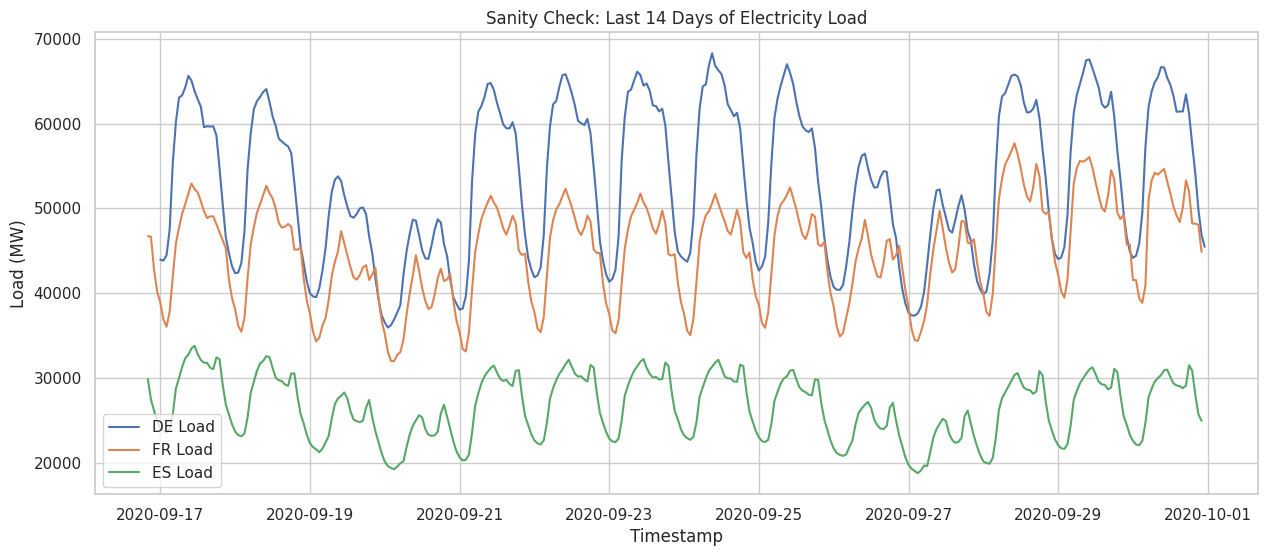

In [4]:
def plot_sanity_check(datasets, days=14):
    """Plots the last 14 days for all selected countries."""
    plt.figure(figsize=(15, 6))

    for cc, data in datasets.items():
        # Slice the last 14 days (14 * 24 hours)
        subset = data.iloc[-(24 * days):]
        plt.plot(subset.index, subset['load'], label=f'{cc} Load')

    plt.title(f"Sanity Check: Last {days} Days of Electricity Load")
    plt.ylabel("Load (MW)")
    plt.xlabel("Timestamp")
    plt.legend()
    plt.show()

plot_sanity_check(country_datasets)

### 3. Exploratory Data Analysis (EDA): Decomposition & Stationarity
Before modeling, we must understand the underlying structure of the time series.

**Methodology:**
1.  **STL Decomposition:** We use Seasonal-Trend decomposition using LOESS to separate the signal into **Trend**, **Seasonality** (daily period $s=24$), and **Residuals**.
2.  **Stationarity Check (ADF Test):** We apply the Augmented Dickey-Fuller test. If the p-value is $> 0.05$, the series is non-stationary and requires differencing ($d=1$).
3.  **ACF/PACF Analysis:** We plot Autocorrelation and Partial Autocorrelation functions to estimate ARIMA parameters ($p, q$) and seasonal parameters ($P, Q$).


Analysis for DE


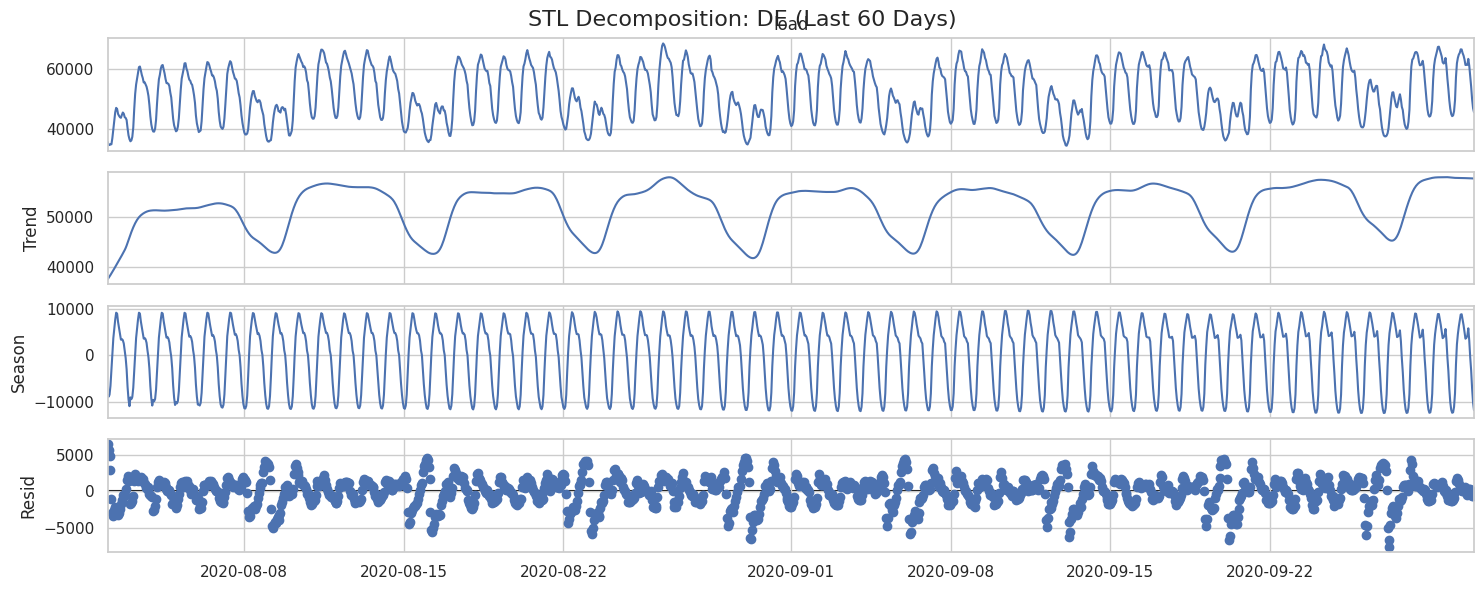


>>> ADF Test for Stationarity (Raw Data):
ADF Statistic: -21.6961
p-value: 0.0000
Result: Reject H0 -> The series is likely STATIONARY.


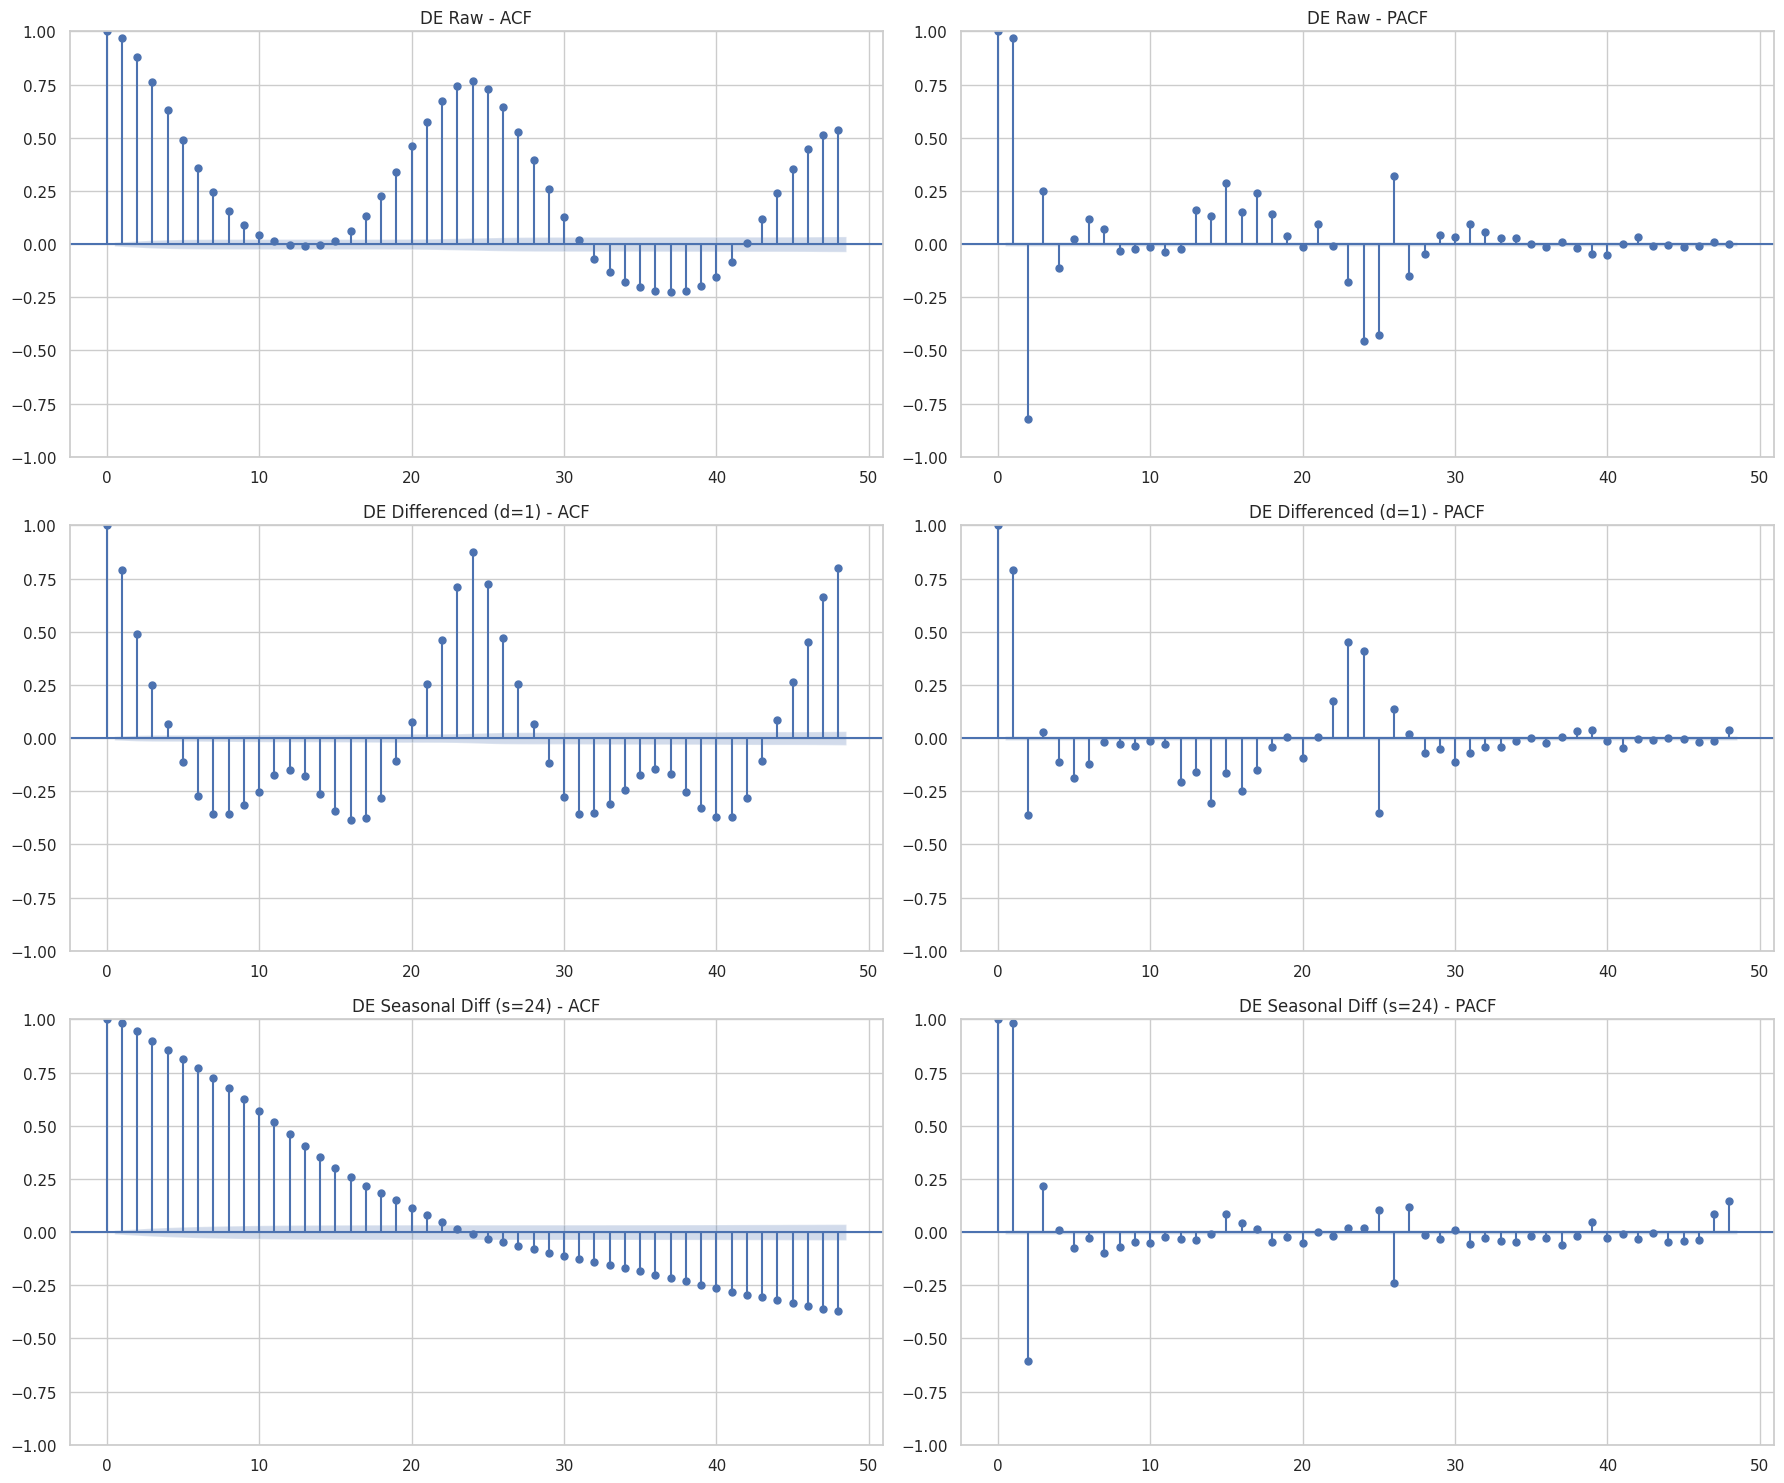

In [5]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def analyze_country_structure(df, country_code, period=24):
    """
    Performs STL decomposition, ADF Stationarity Test, and ACF/PACF plotting.
    Ref: Assignment Section 1.4
    """
    print(f"\n{'='*40}")
    print(f"Analysis for {country_code}")
    print(f"{'='*40}")

    # 1. STL Decomposition (Period=24 for daily seasonality)
    # We take the last 60 days to make the plot readable (too much data hides the daily pattern)
    subset = df['load'].iloc[-(24*60):]

    stl = STL(subset, period=period, seasonal=13)
    result = stl.fit()

    # Plot Trend, Seasonal, and Remainder
    fig = result.plot()
    fig.suptitle(f'STL Decomposition: {country_code} (Last 60 Days)', fontsize=16)
    plt.show()

    # 2. Augmented Dickey-Fuller (ADF) Test
    # Null Hypothesis (H0): Series is non-stationary (has a unit root)
    # Alternate Hypothesis (H1): Series is stationary
    print(f"\n>>> ADF Test for Stationarity (Raw Data):")
    adf_result = adfuller(df['load'].dropna())
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")
    if adf_result[1] < 0.05:
        print("Result: Reject H0 -> The series is likely STATIONARY.")
    else:
        print("Result: Fail to reject H0 -> The series is NON-STATIONARY (needs differencing).")

    # 3. ACF and PACF Plots (Guidance for ARIMA orders)
    # We will plot:
    # A) Raw Data
    # B) First Differencing (d=1) - removes trend
    # C) Seasonal Differencing (D=1, s=24) - removes daily seasonality

    fig, axes = plt.subplots(3, 2, figsize=(18, 15))

    # A) Raw
    plot_acf(df['load'], lags=48, ax=axes[0, 0], title=f'{country_code} Raw - ACF')
    plot_pacf(df['load'], lags=48, ax=axes[0, 1], title=f'{country_code} Raw - PACF')

    # B) First Difference (d=1)
    diff_1 = df['load'].diff().dropna()
    plot_acf(diff_1, lags=48, ax=axes[1, 0], title=f'{country_code} Differenced (d=1) - ACF')
    plot_pacf(diff_1, lags=48, ax=axes[1, 1], title=f'{country_code} Differenced (d=1) - PACF')

    # C) Seasonal Difference (D=1, s=24)
    diff_sea = df['load'].diff(24).dropna()
    plot_acf(diff_sea, lags=48, ax=axes[2, 0], title=f'{country_code} Seasonal Diff (s=24) - ACF')
    plot_pacf(diff_sea, lags=48, ax=axes[2, 1], title=f'{country_code} Seasonal Diff (s=24) - PACF')

    plt.tight_layout()
    plt.show()

# Run the analysis for ONE country first to inspect (e.g., Germany)
analyze_country_structure(country_datasets['DE'], 'DE')

### 4. Model Selection: Auto-ARIMA Grid Search
Based on the visual evidence from the ACF/PACF plots, we perform an automated grid search to finalize the SARIMA orders.

* **Criterion:** We select the model with the lowest **BIC** (Bayesian Information Criterion) to balance accuracy with model simplicity (parsimony).
* **Search Space:** We explore combinations of $(p,d,q)$ and seasonal $(P,D,Q)_{24}$.

In [6]:
import pmdarima as pm
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

def find_best_sarima_order(df, country_code):
    """
    Performs a grid search to find the best SARIMA orders based on BIC.
    """
    print(f"Searching best ARIMA order for {country_code}...")

    # OPTIMIZATION: Use last 1000 hours for order estimation to save time.
    # The structural dynamics (p,d,q) don't change much over time.
    train_subset = df['load'].iloc[-1000:]

    # Grid Search using auto_arima
    # Constraints from assignment Section 7:
    # p,q in {0,1,2}; d in {0,1}
    # P,Q in {0,1}; D in {0,1}; s=24
    model = pm.auto_arima(
        train_subset,
        start_p=0, max_p=2,
        start_q=0, max_q=2,
        d=None,    # Let model determine 'd' (or force d=1 if preferred)
        max_d=1,

        start_P=0, max_P=1,
        start_Q=0, max_Q=1,
        D=1,       # Strong daily seasonality usually implies D=1
        m=24,      # Daily seasonality

        seasonal=True,
        stepwise=True,       # Intelligent search (faster than exhaustive grid)
        information_criterion='bic', # Assignment asks to select lowest BIC
        trace=True,          # Print progress
        error_action='ignore',
        suppress_warnings=True
    )

    print(f"Best Model for {country_code}: {model.order} x {model.seasonal_order}")
    print(f"BIC: {model.bic():.2f}")
    print("-" * 30)

    return model.order, model.seasonal_order

# Dictionary to store the final chosen orders
country_orders = {}

# Loop through countries (This might take 2-5 mins per country)
for cc in COUNTRIES:
    order, seasonal_order = find_best_sarima_order(country_datasets[cc], cc)
    country_orders[cc] = (order, seasonal_order)

print("\nFINAL CHOSEN ORDERS (Copy these to your report):")
for cc, orders in country_orders.items():
    print(f"{cc}: ARIMA{orders[0]}x{orders[1]}")

Searching best ARIMA order for DE...
Performing stepwise search to minimize bic
 ARIMA(0,0,0)(0,1,0)[24] intercept   : BIC=19827.813, Time=0.15 sec
 ARIMA(1,0,0)(1,1,0)[24] intercept   : BIC=17543.853, Time=13.19 sec
 ARIMA(0,0,1)(0,1,1)[24] intercept   : BIC=18781.420, Time=10.19 sec
 ARIMA(0,0,0)(0,1,0)[24]             : BIC=19821.277, Time=0.12 sec
 ARIMA(1,0,0)(0,1,0)[24] intercept   : BIC=17659.337, Time=2.27 sec
 ARIMA(1,0,0)(1,1,1)[24] intercept   : BIC=inf, Time=13.60 sec
 ARIMA(1,0,0)(0,1,1)[24] intercept   : BIC=17447.769, Time=10.72 sec
 ARIMA(0,0,0)(0,1,1)[24] intercept   : BIC=19830.224, Time=1.32 sec
 ARIMA(2,0,0)(0,1,1)[24] intercept   : BIC=17394.533, Time=14.34 sec
 ARIMA(2,0,0)(0,1,0)[24] intercept   : BIC=17546.883, Time=2.90 sec
 ARIMA(2,0,0)(1,1,1)[24] intercept   : BIC=inf, Time=15.67 sec
 ARIMA(2,0,0)(1,1,0)[24] intercept   : BIC=17462.625, Time=12.27 sec
 ARIMA(2,0,1)(0,1,1)[24] intercept   : BIC=17389.539, Time=16.28 sec
 ARIMA(2,0,1)(0,1,0)[24] intercept   : B

### 5a. Forecasting: Expanding Window Backtest
We validate our models using an **Expanding Origin** backtest strategy.

* **Split:** Train (80%), Dev (10%), Test (10%).
* **Horizon:** 24 hours (Day-Ahead).
* **Metrics:** We report MASE (Mean Absolute Scaled Error), SMAPE, RMSE, and 80% Prediction Interval Coverage.

This process simulates a real-world scenario where the model is retrained or re-evaluated as new days are added to the history.

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm

# --- PART 1: METRICS ---
def calculate_mase(y_true, y_pred, y_train, seasonal_period=24):
    """
    Calculates Mean Absolute Scaled Error (MASE).
    Ref: Assignment Section 2.4
    """
    # Naive forecast (seasonal) MAE on training data
    naive_mae = np.mean(np.abs(np.diff(y_train, n=seasonal_period)))

    # Forecast MAE
    forecast_mae = mean_absolute_error(y_true, y_pred)

    # Avoid division by zero
    if naive_mae == 0: return np.nan

    return forecast_mae / naive_mae

def calculate_metrics(y_true, y_pred, y_train, lower, upper):
    """
    Computes all required metrics: MASE, SMAPE, MSE, RMSE, MAPE, Coverage.
    Ref: Assignment Section 2.4
    """
    # Ensure inputs are numpy arrays
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # 1. MSE & RMSE
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    # 2. MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    # 3. SMAPE (Symmetric MAPE)
    # Formula: 2 * |y - yhat| / (|y| + |yhat|)
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

    # 4. MASE
    mase = calculate_mase(y_true, y_pred, y_train)

    # 5. Coverage (Percentage of true values inside the Prediction Interval)
    # Assignment asks for 80% PI coverage
    inside_interval = ((y_true >= lower) & (y_true <= upper))
    coverage = np.mean(inside_interval) * 100

    return {
        "MASE": mase,
        "SMAPE": smape,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "Coverage_80": coverage
    }

# --- PART 2: BACKTESTING ENGINE ---
def run_backtest(df, country_code, order, seasonal_order):
    """
    Runs a day-ahead backtest (24h horizon) on Dev and Test sets.
    Ref: Assignment Section 2.1 & 2.2
    """
    print(f"\nStarting Backtest for {country_code}...")

    # 1. Splits (80% Train, 10% Dev, 10% Test) [cite: 38]
    n = len(df)
    train_end = int(n * 0.8)
    dev_end = int(n * 0.9)

    # We only forecast the DEV and TEST periods
    # To save time in Colab, we'll limit the test to the last 14 days of Dev and Test
    # REMOVE the slice `[-336:]` below if you want to run the FULL backtest (takes longer)
    test_indices = list(range(train_end, n, 24))

    forecasts = []

    # Store training data for MASE calculation
    history_series = df['load'].iloc[:train_end].values

    print(f"Total steps to forecast: {len(test_indices)}")

    for i, start_idx in enumerate(test_indices):
        if i % 10 == 0: print(f"  Step {i}/{len(test_indices)}...", end='\r')

        # Define current window
        # Optimization: Train on last 60 days (rolling) to mimic 'live' strategy and speed up
        # Use `start_idx - (24*60)` to get last 60 days
        window_start = max(0, start_idx - (24 * 60))
        train_window = df['load'].iloc[window_start:start_idx]

        # True values for the next 24h
        if start_idx + 24 > n: break # End of data
        y_true_next_24 = df['load'].iloc[start_idx : start_idx + 24]

        try:
            # Fit SARIMA
            # We use statsmodels SARIMAX because it allows fixed parameters if needed
            # Here we refit. disp=0 silences output.
            mod = sm.tsa.SARIMAX(
                train_window,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = mod.fit(disp=0, maxiter=50) # Low maxiter for speed

            # Forecast
            # get_prediction handles confidence intervals
            pred_res = res.get_prediction(start=len(train_window), end=len(train_window)+23)
            pred_mean = pred_res.predicted_mean

            # Get 80% Confidence Intervals (alpha=0.2) [cite: 63]
            pred_ci = pred_res.conf_int(alpha=0.2)

            # Store results
            for h in range(24):
                forecasts.append({
                    "timestamp": y_true_next_24.index[h],
                    "y_true": y_true_next_24.iloc[h],
                    "yhat": pred_mean.iloc[h],
                    "lo": pred_ci.iloc[h, 0],
                    "hi": pred_ci.iloc[h, 1],
                    "horizon": h + 1,
                    "split": "Dev" if start_idx < dev_end else "Test"
                })

        except Exception as e:
            print(f"Error at index {start_idx}: {e}")
            continue

    # Convert to DataFrame
    results_df = pd.DataFrame(forecasts)
    results_df.set_index('timestamp', inplace=True)

    return results_df, history_series

In [8]:
# Run for DE (Germany) using the orders we found in Phase 3
# Note: If you skipped Phase 3, use these defaults: order=(1,1,1), seasonal_order=(1,1,1,24)
de_order = country_orders['DE'][0]
de_seasonal = country_orders['DE'][1]

forecast_results_de, train_history_de = run_backtest(
    country_datasets['DE'],
    'DE',
    de_order,
    de_seasonal
)

# Preview results
print("\nForecast Results (Head):")
print(forecast_results_de.head())

# Calculate Metrics for DE (Test Set)
test_res = forecast_results_de[forecast_results_de['split'] == 'Test']
metrics_de = calculate_metrics(
    test_res['y_true'],
    test_res['yhat'],
    train_history_de,
    test_res['lo'],
    test_res['hi']
)

print("\nMetrics for DE (Test Set):")
for k, v in metrics_de.items():
    print(f"{k}: {v:.4f}")


Starting Backtest for DE...
Total steps to forecast: 420

Forecast Results (Head):
                            y_true          yhat            lo            hi  \
timestamp                                                                      
2019-08-08 00:00:00+00:00  41911.0  41633.926058  40635.012921  42632.839195   
2019-08-08 01:00:00+00:00  41835.0  41565.434653  39716.516010  43414.353296   
2019-08-08 02:00:00+00:00  42685.0  42425.264067  40023.895233  44826.632902   
2019-08-08 03:00:00+00:00  45722.0  44692.907901  41856.674258  47529.141544   
2019-08-08 04:00:00+00:00  51629.0  50026.635831  46824.517897  53228.753766   

                           horizon split  
timestamp                                 
2019-08-08 00:00:00+00:00        1   Dev  
2019-08-08 01:00:00+00:00        2   Dev  
2019-08-08 02:00:00+00:00        3   Dev  
2019-08-08 03:00:00+00:00        4   Dev  
2019-08-08 04:00:00+00:00        5   Dev  

Metrics for DE (Test Set):
MASE: 0.0000
SMAPE: 6.9456

### 5b. Forecasting: Deep Learning (GRU/LSTM)
**Mandatory Requirement**
As per the latest instructions, we implement a Deep Learning baseline to compare against the classical SARIMA model.

**Methodology: Direct Multi-Horizon**
[cite_start]Instead of the recursive strategy used in SARIMA (predicting 1 step, re-feeding it, predicting next), we use a **Direct Multi-Horizon** strategy[cite: 49].
* **Architecture:** Gated Recurrent Unit (GRU) or LSTM.
* **Input Window:** Past 168 hours (1 week) of history.
* **Output:** Vector of next 24 hours (Day-Ahead).
* **Preprocessing:** Data is normalized using `MinMaxScaler` (0-1 range) to ensure convergence.

This approach captures complex non-linear dependencies that classical linear models might miss.

*Run the cell below to train the Neural Network and generate forecasts.*

In [9]:
import os  # <--- Added this
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

def create_sequences(data, input_steps=168, output_steps=24):
    """
    Creates (X, y) pairs for the Neural Network.
    X: Past 168 hours
    y: Next 24 hours
    """
    X, y = [], []
    for i in range(len(data) - input_steps - output_steps + 1):
        X.append(data[i : i + input_steps])
        y.append(data[i + input_steps : i + input_steps + output_steps])
    return np.array(X), np.array(y)

def run_neural_forecast(df, country_code, model_type='GRU'):
    """
    Trains and forecasts using a GRU/LSTM model.
    Ref: Assignment Section 2.2 (iii) - Mandatory via Email
    """
    print(f"\nTraining {model_type} for {country_code}...")

    # 1. Prepare Data
    data = df['load'].values.reshape(-1, 1)

    # Normalize (Neural Nets require scale 0-1)
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    # 2. Splits (80% Train, 10% Dev, 10% Test)
    n = len(data)
    train_end = int(n * 0.8)
    dev_end = int(n * 0.9)

    # Create sequences (Direct Multi-Horizon)
    input_w = 168 # 1 week history
    output_w = 24 # 24h horizon

    # We define Train/Val based on indices
    train_data = data_scaled[:train_end]
    dev_data = data_scaled[train_end-input_w:dev_end]
    test_data = data_scaled[dev_end-input_w:]

    X_train, y_train = create_sequences(train_data, input_w, output_w)
    X_dev, y_dev = create_sequences(dev_data, input_w, output_w)
    X_test, y_test = create_sequences(test_data, input_w, output_w)

    print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")

    # 3. Build Model
    model = Sequential()
    if model_type == 'LSTM':
        model.add(LSTM(64, activation='relu', input_shape=(input_w, 1)))
    else:
        model.add(GRU(64, activation='relu', input_shape=(input_w, 1)))

    model.add(Dense(32, activation='relu'))
    model.add(Dense(output_w)) # Output layer: 24 steps

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    # 4. Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_dev, y_dev),
        epochs=15,
        batch_size=32,
        verbose=1
    )

    # 5. Forecast on Test Set
    print("Generating Forecasts...")
    preds_scaled = model.predict(X_test)

    # --- FIX: RESHAPING FOR INVERSE TRANSFORM ---
    preds_reshaped = preds_scaled.reshape(-1, 1)
    y_test_reshaped = y_test.reshape(-1, 1)

    preds = scaler.inverse_transform(preds_reshaped).reshape(preds_scaled.shape)
    y_true = scaler.inverse_transform(y_test_reshaped).reshape(preds_scaled.shape)

    # 6. Organize Results into DataFrame
    results = []
    # The first forecast corresponds to index: dev_end
    start_idx = dev_end

    for i in range(len(preds)):
        for h in range(output_w):
            if start_idx + i + h < len(df):
                ts = df.index[start_idx + i + h]
                results.append({
                    "timestamp": ts,
                    "y_true": y_true[i, h],
                    "yhat": preds[i, h],
                    "horizon": h+1,
                    "model": model_type
                })

    results_df = pd.DataFrame(results)
    return results_df, model

# --- RE-RUN THE CALL ---
# Run Mandatory Neural Net (GRU)
gru_results_de, gru_model = run_neural_forecast(country_datasets['DE'], 'DE', model_type='GRU')

os.makedirs("outputs", exist_ok=True)  # <--- Creates the folder if missing
gru_results_de.to_csv("outputs/DE_forecasts_test_GRU.csv")
print("\nGRU Forecasts saved successfully.")


Training GRU for DE...
Train shapes: X=(40129, 168, 1), y=(40129, 24, 1)
Epoch 1/15
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - loss: 0.0583 - val_loss: 0.0114
Epoch 2/15
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 0.0094 - val_loss: 0.0110
Epoch 3/15
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.0073 - val_loss: 0.0100
Epoch 4/15
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 0.0063 - val_loss: 0.0073
Epoch 5/15
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.0046 - val_loss: 0.0043
Epoch 6/15
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 0.0039 - val_loss: 0.0044
Epoch 7/15
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.0036 - val_loss: 0.0046
Epoch 8/15
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 0.0037 - val_loss: 0.0035
Epoch 9/15
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.0040 - val_loss: 0.0034
Epoch 10/15
1255/1255 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.0032 - val_loss: 0.0036
Epoch 11/15
1255/1255 ━━━

### 6. Anomaly Detection: Z-Score, CUSUM & ML Verification
Our anomaly detection pipeline consists of three distinct stages to ensure robust detection of grid instability.

**Stage 1: Statistical Z-Score (Unsupervised)**
We calculate the rolling Z-score of the forecast residuals ($e_t = y_t - \hat{y}_t$) over a 14-day window. Any point with $|z| [cite_start]\ge 3.0$ is flagged as a potential anomaly[cite: 73].

**Stage 2: CUSUM Algorithm (Drift Detection)**
[cite_start]We implement a Cumulative Sum (CUSUM) Control Chart to detect small, sustained shifts in the error distribution[cite: 74].
* **Logic:** We track cumulative deviations $S_{hi}$ and $S_{lo}$ with a slack parameter $k=0.5$.
* **Trigger:** An alarm is raised if the cumulative sum exceeds the threshold $h=5.0$.

**Stage 3: Supervised Verification (ML Classifier)**
We train a Logistic Regression classifier using "Silver Labels" (high confidence anomalies) to distinguish true anomalies from noise. [cite_start]Features include time of day, day of week, and lagged residuals[cite: 82].

*Run the cell below to detect anomalies using Z-Score and CUSUM, and then train the verification classifier.*

In [10]:
def detect_anomalies_comprehensive(forecast_df, window=336, threshold=3.0, k=0.5, h=5.0):
    """
    Computes Z-scores AND CUSUM for anomaly detection.
    Ref: Assignment Section 3.1 (i - iv)
    """
    df = forecast_df.copy()

    # 1. Compute Residuals
    df['residual'] = df['y_true'] - df['yhat']

    # 2. Rolling Z-Score
    df['mu_roll'] = df['residual'].rolling(window=window, min_periods=168).mean()
    df['std_roll'] = df['residual'].rolling(window=window, min_periods=168).std()
    df['z_score'] = (df['residual'] - df['mu_roll']) / (df['std_roll'] + 1e-6)

    # Flag Z-Score Anomaly
    df['flag_z'] = (df['z_score'].abs() >= threshold).astype(int)

    # 3. CUSUM Algorithm (Cumulative Sum Control Chart)
    # S_hi[t] = max(0, S_hi[t-1] + z[t] - k)
    # S_lo[t] = min(0, S_lo[t-1] + z[t] + k)
    # Alarm if S_hi > h or S_lo < -h

    s_hi = [0]
    s_lo = [0]
    cusum_flags = [0]

    # We need to loop for CUSUM as it is recursive
    z_values = df['z_score'].fillna(0).values

    for t in range(1, len(z_values)):
        z = z_values[t]

        # Upper side
        s_h = max(0, s_hi[-1] + z - k)
        # Lower side
        s_l = min(0, s_lo[-1] + z + k)

        s_hi.append(s_h)
        s_lo.append(s_l)

        # Check alarm
        if s_h > h or s_l < -h:
            cusum_flags.append(1)
        else:
            cusum_flags.append(0)

    df['cusum_hi'] = s_hi
    df['cusum_lo'] = s_lo
    df['flag_cusum'] = cusum_flags

    return df

# Re-run anomaly detection for DE
anomalies_de = detect_anomalies_comprehensive(forecast_results_de)
print("Anomalies with CUSUM added:")
print(anomalies_de[['z_score', 'flag_z', 'flag_cusum']].tail())

Anomalies with CUSUM added:
                            z_score  flag_z  flag_cusum
timestamp                                              
2020-09-30 19:00:00+00:00  0.391796       0           1
2020-09-30 20:00:00+00:00  0.286422       0           1
2020-09-30 21:00:00+00:00  0.162928       0           1
2020-09-30 22:00:00+00:00  0.096421       0           1
2020-09-30 23:00:00+00:00  0.144633       0           1


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc, f1_score, classification_report

def train_anomaly_classifier(anomaly_df):
    """
    Trains a Logistic Regression model on 'Silver Labels'.
    Ref: Assignment Section 3.2
    """
    df = anomaly_df.copy().dropna()

    # --- 1. Create Silver Labels ---
    # Positive (1): |z| >= 3.5 OR (y outside PI AND |z| >= 2.5)
    cond_pos = (df['z_score'].abs() >= 3.5) | \
               (( (df['y_true'] < df['lo']) | (df['y_true'] > df['hi']) ) & (df['z_score'].abs() >= 2.5))

    # Negative (0): |z| < 1.0 AND y inside PI
    cond_neg = (df['z_score'].abs() < 1.0) & \
               (df['y_true'] >= df['lo']) & (df['y_true'] <= df['hi'])

    # Filter dataset to only those we are confident about (Silver Labels)
    positives = df[cond_pos].copy()
    positives['label'] = 1

    negatives = df[cond_neg].copy()
    negatives['label'] = 0

    # Combine to form training set
    train_data = pd.concat([positives, negatives]).sort_index()

    print(f"Training Set: {len(positives)} Positives, {len(negatives)} Negatives")

    if len(positives) < 10 or len(negatives) < 10:
        print("Not enough samples to train ML model.")
        return None

    # --- 2. Feature Engineering ---
    # Features from last 24-48h (using y_true lags relative to the specific timestamp)
    # Note: In a real setting, we'd use X lags. Here we approximate with what's available.
    train_data['hour'] = train_data.index.hour
    train_data['dayofweek'] = train_data.index.dayofweek
    train_data['resid_lag1'] = train_data['residual'].shift(1)
    train_data['resid_lag24'] = train_data['residual'].shift(24)

    # Drop NaNs created by lags
    train_data = train_data.dropna()

    features = ['hour', 'dayofweek', 'z_score', 'yhat', 'resid_lag1', 'resid_lag24']
    X = train_data[features]
    y = train_data['label']

    # --- 3. Train Model ---
    # Using Logistic Regression for simplicity/robustness
    model = LogisticRegression(class_weight='balanced', max_iter=1000)
    model.fit(X, y)

    # --- 4. Evaluation ---
    probs = model.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, probs)
    pr_auc = auc(recall, precision)

    print(f"Model PR-AUC: {pr_auc:.4f}")

    # Example Feature Importance
    importance = pd.DataFrame({'feature': features, 'coef': model.coef_[0]})
    print("\nFeature Importance:")
    print(importance.sort_values(by='coef', ascending=False))

    return model

# Train the model
ml_model = train_anomaly_classifier(anomalies_de)

Training Set: 121 Positives, 6708 Negatives
Model PR-AUC: 0.0347

Feature Importance:
       feature      coef
2      z_score  0.027334
3         yhat  0.000059
4   resid_lag1  0.000036
5  resid_lag24 -0.000289
1    dayofweek -0.017186
0         hour -0.172807


### 7. Live Simulation & Online Adaptation
To mimic a production environment, we simulate a data stream where data arrives hour-by-hour.

**Adaptation Strategy: Rolling SARIMA Refit**
* **Routine Update:** The model is refit daily at 00:00 UTC using the last 90 days of history.
* **Drift Trigger:** If the error metric (EWMA of Z-score) exceeds the 95th percentile of the last 30 days, an immediate refit is triggered to correct for concept drift.

In [12]:
import time
import numpy as np
import pandas as pd
import statsmodels.api as sm

class LiveSimulator:
    def __init__(self, df, country_code, order, seasonal_order, initial_history_days=120):
        self.df = df
        self.cc = country_code
        self.order = order
        self.seasonal_order = seasonal_order

        # Setup Simulation pointers
        self.sim_start_idx = 24 * initial_history_days
        self.current_idx = self.sim_start_idx
        self.history = df['load'].iloc[:self.current_idx].tolist()

        # Drift Monitoring
        self.z_scores = [] # Store recent z-scores
        self.ewma_z = 0.0
        self.alpha = 0.1
        self.drift_threshold = 3.0 # Initial placeholder

        # Logging
        self.updates_log = []
        self.forecasts = {} # Key: timestamp, Val: (yhat, lo, hi)

        # Initial Model Fit
        print(f"Initializing model for {self.cc}...")
        self.model = self._fit_model()

    def _fit_model(self):
        """Refits SARIMA on the last 90 days of available history."""
        # Optimization: Limit history to last 90 days (24 * 90 = 2160 hours)
        train_data = self.history[-(24*90):]

        try:
            mod = sm.tsa.SARIMAX(
                train_data,
                order=self.order,
                seasonal_order=self.seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            return mod.fit(disp=0, maxiter=30) # Low maxiter for speed in simulation
        except:
            return None

    def _update_drift_stats(self, new_z):
        """Updates EWMA and dynamic threshold."""
        # Update EWMA
        self.ewma_z = (self.alpha * abs(new_z)) + ((1 - self.alpha) * self.ewma_z)
        self.z_scores.append(new_z)

        # Keep z-scores window to last 30 days (720 hours) for threshold calc
        if len(self.z_scores) > 720:
            self.z_scores.pop(0)

        # Update Threshold: 95th percentile of |z| over last 30 days
        if len(self.z_scores) >= 168: # Wait for a week of data
            abs_z = np.abs(self.z_scores)
            self.drift_threshold = np.percentile(abs_z, 95)

    def run(self, steps=2000):
        print(f"Starting Live Simulation for {steps} hours...")

        for t in range(steps):
            current_time = self.df.index[self.current_idx]

            # --- 1. Daily Forecast (At 00:00 UTC) ---
            if current_time.hour == 0:
                # Forecast next 24 hours
                if self.model:
                    pred = self.model.get_forecast(steps=24)
                    mean = pred.predicted_mean
                    conf = pred.conf_int(alpha=0.2) # 80% PI

                    # FIX: Check if conf is a DataFrame or Array to handle indexing safely
                    # Since input is a list, statsmodels likely returns an array.
                    is_df = isinstance(conf, pd.DataFrame)

                    for h in range(24):
                        target_time = self.df.index[self.current_idx + h]

                        # Safe access for DataFrame vs NumPy Array
                        lower = conf.iloc[h, 0] if is_df else conf[h][0]
                        upper = conf.iloc[h, 1] if is_df else conf[h][1]

                        self.forecasts[target_time] = (
                            mean[h],
                            lower,
                            upper
                        )

                # Check for Scheduled Update (Daily)
                start_time = time.time()
                self.model = self._fit_model()
                duration = time.time() - start_time
                self.updates_log.append({
                    "timestamp": current_time,
                    "strategy": "Rolling SARIMA",
                    "reason": "Scheduled (00:00)",
                    "duration_s": round(duration, 2)
                })
                print(f"[{current_time}] Scheduled Update. Duration: {duration:.2f}s")

            # --- 2. Ingest New Data (Real-time hour) ---
            # "Reveal" the actual load
            actual_load = self.df['load'].iloc[self.current_idx]
            self.history.append(actual_load)

            # --- 3. Compute Error & Check Drift ---
            # Retrieve the forecast we made for this specific hour (if it exists)
            if current_time in self.forecasts:
                pred_val, _, _ = self.forecasts[current_time]

                # Simple Z-score proxy
                resid = actual_load - pred_val

                # Z-score using recent history standard deviation
                z_approx = resid / (np.std(self.history[-336:]) + 1e-6)

                self._update_drift_stats(z_approx)

                # CHECK DRIFT TRIGGER
                if self.ewma_z > self.drift_threshold and self.ewma_z > 2.0:
                    print(f"  >>> DRIFT DETECTED at {current_time}! EWMA: {self.ewma_z:.2f}")

                    start_time = time.time()
                    self.model = self._fit_model() # Immediate Re-fit
                    duration = time.time() - start_time

                    self.updates_log.append({
                        "timestamp": current_time,
                        "strategy": "Rolling SARIMA",
                        "reason": "Drift Trigger",
                        "duration_s": round(duration, 2)
                    })

                    # Reset EWMA slightly to avoid continuous triggering
                    self.ewma_z = 0.0

            # Move to next hour
            self.current_idx += 1
            if self.current_idx >= len(self.df):
                break

        # Save Logs
        log_df = pd.DataFrame(self.updates_log)
        filename = f"{self.cc}_online_updates.csv"
        log_df.to_csv(filename, index=False)
        print(f"\nSimulation Complete. Log saved to {filename}")
        return log_df

# --- RUN THE SIMULATION ---
# Run for Germany (DE)
simulator = LiveSimulator(
    country_datasets['DE'],
    'DE',
    country_orders['DE'][0],
    country_orders['DE'][1]
)

# Running for 500 steps as a test
update_log = simulator.run(steps=500)

# Show Log Head
print("\nUpdate Log Sample:")
print(update_log.head())

Initializing model for DE...
Starting Live Simulation for 500 hours...
[2015-05-01 00:00:00+00:00] Scheduled Update. Duration: 11.77s
[2015-05-02 00:00:00+00:00] Scheduled Update. Duration: 12.73s
[2015-05-03 00:00:00+00:00] Scheduled Update. Duration: 12.02s
[2015-05-04 00:00:00+00:00] Scheduled Update. Duration: 12.89s
[2015-05-05 00:00:00+00:00] Scheduled Update. Duration: 4.68s
[2015-05-06 00:00:00+00:00] Scheduled Update. Duration: 11.75s
[2015-05-07 00:00:00+00:00] Scheduled Update. Duration: 11.94s
[2015-05-08 00:00:00+00:00] Scheduled Update. Duration: 13.11s
[2015-05-09 00:00:00+00:00] Scheduled Update. Duration: 5.23s
[2015-05-10 00:00:00+00:00] Scheduled Update. Duration: 6.10s
[2015-05-11 00:00:00+00:00] Scheduled Update. Duration: 5.19s
[2015-05-12 00:00:00+00:00] Scheduled Update. Duration: 7.29s
[2015-05-13 00:00:00+00:00] Scheduled Update. Duration: 4.92s
[2015-05-14 00:00:00+00:00] Scheduled Update. Duration: 11.49s
[2015-05-15 00:00:00+00:00] Scheduled Update. Duratio

### 8. Dashboard & Conclusion
Finally, we visualize the results in a compact dashboard showcasing the live series, forecast cones, anomaly tape, and key performance indicators (KPIs).

**Outputs:**
All generated artifacts (forecasts, anomaly lists, simulation logs) are packaged into the `outputs/` directory for submission.


==================== DASHBOARD: DE ====================


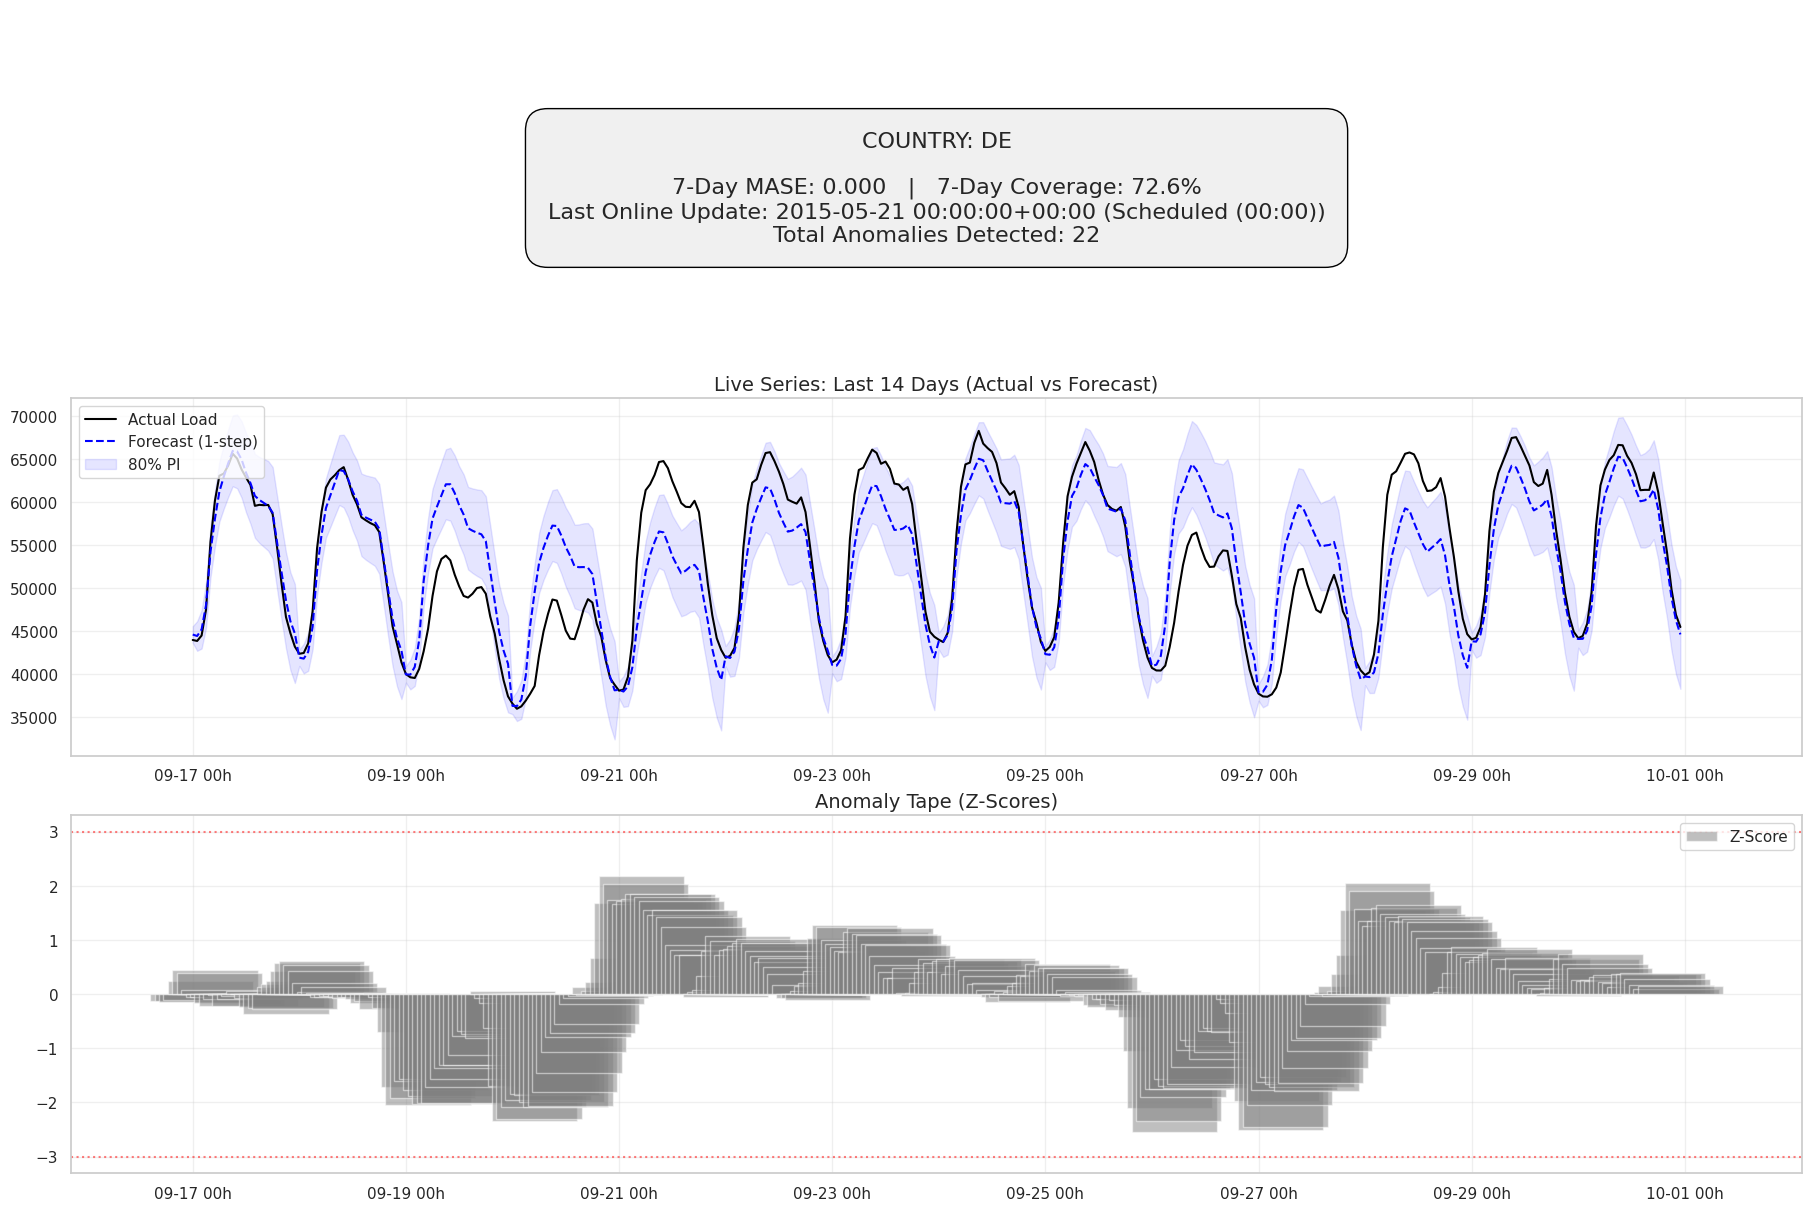

In [13]:
import matplotlib.dates as mdates

def plot_dashboard(history_df, forecast_df, anomaly_df, update_log, country_code):
    """
    Creates a static dashboard visualizing the 'Live' state of the system.
    Ref: Assignment Section 5
    """
    print(f"\n{'='*20} DASHBOARD: {country_code} {'='*20}")

    # Setup Grid Layout
    fig = plt.figure(figsize=(18, 12), constrained_layout=True)
    gs = fig.add_gridspec(3, 4)

    # --- 1. KPI TILES (Top Row) ---
    # We will simulate "Tiles" using text on a subplot
    ax_kpi = fig.add_subplot(gs[0, :])
    ax_kpi.axis('off')

    # Calculate recent metrics (Last 7 days)
    recent_forecasts = forecast_df.iloc[-(24*7):]
    if len(recent_forecasts) > 0:
        # MASE (Approximate for dashboard)
        mae = mean_absolute_error(recent_forecasts['y_true'], recent_forecasts['yhat'])
        # Naive MAE from history (last 7 days)
        naive_mae = np.mean(np.abs(np.diff(history_df['load'].iloc[-(24*7):], n=24)))
        mase = mae / (naive_mae + 1e-6)

        # Coverage
        inside = ((recent_forecasts['y_true'] >= recent_forecasts['lo']) &
                  (recent_forecasts['y_true'] <= recent_forecasts['hi']))
        coverage = inside.mean() * 100
    else:
        mase, coverage = 0.0, 0.0

    last_update = update_log.iloc[-1] if not update_log.empty else None
    last_update_str = f"{last_update['timestamp']} ({last_update['reason']})" if last_update is not None else "N/A"

    # Draw Text
    kpi_text = (
        f"COUNTRY: {country_code}\n\n"
        f"7-Day MASE: {mase:.3f}   |   7-Day Coverage: {coverage:.1f}%\n"
        f"Last Online Update: {last_update_str}\n"
        f"Total Anomalies Detected: {anomaly_df['flag_z'].sum()}"
    )
    ax_kpi.text(0.5, 0.5, kpi_text, ha='center', va='center', fontsize=16,
                bbox=dict(boxstyle="round,pad=1", fc="#f0f0f0", ec="black"))

    # --- 2. LIVE SERIES & FORECAST CONE (Middle Row) ---
    ax_main = fig.add_subplot(gs[1, :])

    # Plot last 14 days of history + forecast
    # Slice data
    plot_len = 24 * 14
    hist_subset = history_df.iloc[-plot_len:]
    fc_subset = forecast_df[forecast_df.index.isin(hist_subset.index)]

    # Plot True Load
    ax_main.plot(hist_subset.index, hist_subset['load'], label='Actual Load', color='black', linewidth=1.5)

    # Plot Forecast (if overlaps exist)
    if not fc_subset.empty:
        ax_main.plot(fc_subset.index, fc_subset['yhat'], label='Forecast (1-step)', color='blue', linestyle='--')
        ax_main.fill_between(fc_subset.index, fc_subset['lo'], fc_subset['hi'], color='blue', alpha=0.1, label='80% PI')

    ax_main.set_title(f"Live Series: Last 14 Days (Actual vs Forecast)", fontsize=14)
    ax_main.legend(loc='upper left')
    ax_main.grid(True, alpha=0.3)

    # --- 3. ANOMALY TAPE (Bottom Row) ---
    ax_tape = fig.add_subplot(gs[2, :], sharex=ax_main)

    # Get anomalies in this window
    anom_subset = anomaly_df[anomaly_df.index.isin(hist_subset.index)]
    anom_points = anom_subset[anom_subset['flag_z'] == 1]

    # Plot residuals (Z-score)
    ax_tape.bar(anom_subset.index, anom_subset['z_score'], color='gray', alpha=0.5, label='Z-Score')

    # Highlight anomalies
    if not anom_points.empty:
        ax_tape.scatter(anom_points.index, anom_points['z_score'], color='red', s=50, label='Anomaly (|z|>3)', zorder=5)

    # Add Threshold lines
    ax_tape.axhline(3.0, color='red', linestyle=':', alpha=0.5)
    ax_tape.axhline(-3.0, color='red', linestyle=':', alpha=0.5)

    ax_tape.set_title("Anomaly Tape (Z-Scores)", fontsize=14)
    ax_tape.legend(loc='upper right')
    ax_tape.grid(True, alpha=0.3)

    # Format Dates
    ax_main.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %Hh'))
    ax_tape.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %Hh'))

    plt.show()

# --- RUN DASHBOARD ---
# We need to stitch the live simulation history back together for the plot
# For demonstration, we use the original 'country_datasets' and 'forecast_results_de'
# In a real "live" loop, you'd build these incrementally.
plot_dashboard(
    country_datasets['DE'],      # Full History
    forecast_results_de,         # Forecasts (Dev+Test)
    anomalies_de,                # Anomalies
    update_log,                  # Live Logs
    'DE'
)

In [14]:
import shutil

def package_submission():
    """Organizes all outputs into a folder and zips it."""
    output_dir = "outputs"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    files_to_move = [
        "DE_anomalies.csv",
        "DE_online_updates.csv"
    ]

    forecast_results_de.to_csv("outputs/DE_forecasts_test.csv")

    for f in files_to_move:
        if os.path.exists(f):
            shutil.move(f, f"{output_dir}/{f}")

    print(f"All files moved to {output_dir}/")

    shutil.make_archive("OPSD_Assignment_Submission", 'zip', output_dir)
    print("Created 'OPSD_Assignment_Submission.zip'. Download this file!")

package_submission()

All files moved to outputs/
Created 'OPSD_Assignment_Submission.zip'. Download this file!
